In [2]:
import open3d as o3d
import numpy as np
from PIL import Image
from scipy.spatial.transform import Rotation as R
import glob
import os
import time
import re
import numpy as np

### Config

In [3]:
DEPTH = "../../../zed2i_depth_image/"
RGB = "../../../zed2i_right_images/"  

fx, fy, cx, cy = 1052.19970703125, 1052.19970703125, 956.3457641601562, 553.95703125
depth_scale = 1000.0   # mm -> meters
depth_trunc = 30.0
frame_delay = 0.05

### Transforms

In [4]:
quat = [-0.45720033826192996, -0.4523183402260819, -0.5455934690231464, 0.5373115821826182]
trans = [-0.012769940823864567, -0.07826319215076401, -0.39482353374563656]

T_boxbase_zed2i = np.eye(4)
T_boxbase_zed2i[:3, :3] = R.from_quat(quat).as_matrix()
T_boxbase_zed2i[:3, 3] = trans

# ROS Optical (+X right, +Y down, +Z forward) to Body frame alignment
T_optical_to_body = np.array([
    [ 0,  0,  1,  0],
    [-1,  0,  0,  0],
    [ 0, -1,  0,  0],
    [ 0,  0,  0,  1]
])

# Combine into single static transform
T_TOTAL = T_boxbase_zed2i @ T_optical_to_body

### Gather Files

In [5]:
def frame_id(path):
    m = re.search(r'(\d+)', os.path.basename(path))
    return int(m.group(1)) if m else 0

rgb_files = sorted(glob.glob(os.path.join(RGB, "*.jpeg")), key=frame_id)
depth_files = sorted(glob.glob(os.path.join(DEPTH, "*.png")), key=frame_id)

### Build PCD

In [6]:
def build_pcd(rgb_path, depth_path):
    rgb = np.array(Image.open(rgb_path).convert("RGB"))
    depth = np.array(Image.open(depth_path))  # uint16, mm

    h, w = depth.shape
    rgb_o3d = o3d.geometry.Image(rgb)
    depth_o3d = o3d.geometry.Image(depth)

    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        rgb_o3d, depth_o3d,
        depth_scale=depth_scale,
        depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )

    intrinsic = o3d.camera.PinholeCameraIntrinsic(w, h, fx, fy, cx, cy)
    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
    
    # Transform from camera optical frame to box_base frame
    pcd.transform(T_TOTAL)
    return pcd

### Plane Fitting

In [7]:
def fit_ground_plane(
    pcd: o3d.geometry.PointCloud,
    distance_threshold: float = 0.05,
    ransac_n: int = 3,
    num_iterations: int = 1000,
    near_field_radius: float | None = 5.0,
    min_inlier_fraction: float = 0.1,
):
    
    points = np.asarray(pcd.points)

    if near_field_radius is not None:
        xy_dist = np.linalg.norm(points[:, :2], axis=1)
        mask = xy_dist <= near_field_radius
        if mask.sum() < ransac_n:
            raise RuntimeError(
                f"Only {mask.sum()} points within near_field_radius="
                f"{near_field_radius} m; need at least {ransac_n}."
            )
        subset_pcd = pcd.select_by_index(np.where(mask)[0])
    else:
        subset_pcd = pcd

    plane_coeffs, inlier_indices = subset_pcd.segment_plane(
        distance_threshold=distance_threshold,
        ransac_n=ransac_n,
        num_iterations=num_iterations,
    )
    plane_coeffs = np.asarray(plane_coeffs)

    inlier_fraction = len(inlier_indices) / len(subset_pcd.points)
    if inlier_fraction < min_inlier_fraction:
        # raise RuntimeError(
        #     f"RANSAC plane fit inlier fraction {inlier_fraction:.2f} "
        #     f"below threshold {min_inlier_fraction}. Fit likely unreliable "
        #     f"(e.g. no clear ground plane in near field)."
        # )
        print("*** RANSAC Fit Unreliable ***")

    # Ensure normal points "up" (positive z component) for a consistent sign
    # convention on height-above-plane later.
    a, b, c, d = plane_coeffs
    if c < 0:
        plane_coeffs = -plane_coeffs

    return plane_coeffs, inlier_indices, subset_pcd


def height_above_plane(points: np.ndarray, plane_coeffs: np.ndarray) -> np.ndarray:
    a, b, c, d = plane_coeffs
    return points @ np.array([a, b, c]) + d

### Visualise Ground Plane

In [28]:
def visualize_ground_plane(
    pcd: o3d.geometry.PointCloud,
    plane_coeffs: np.ndarray,
    inlier_indices: list[int],
    subset_pcd: o3d.geometry.PointCloud | None = None,
    plane_patch_size: float = 6.0,
    show_frame: bool = True,
):
    
    # Color inliers (ground) green, everything else gray
    full_points = np.asarray(pcd.points)
    colors = np.tile([0.6, 0.6, 0.6], (len(full_points), 1))  # gray default

    if subset_pcd is not None:
        # Map inlier indices (into subset) back to indices into the full cloud
        subset_points = np.asarray(subset_pcd.points)
        inlier_pts = subset_points[inlier_indices]
        # Match inlier points back to full cloud via nearest-neighbor lookup
        full_tree = o3d.geometry.KDTreeFlann(pcd)
        full_inlier_idx = []
        for pt in inlier_pts:
            _, idx, _ = full_tree.search_knn_vector_3d(pt, 1)
            full_inlier_idx.append(idx[0])
        colors[full_inlier_idx] = [0.1, 0.9, 0.1]  # green
    else:
        colors[inlier_indices] = [0.1, 0.9, 0.1]

    display_pcd = o3d.geometry.PointCloud(pcd)
    display_pcd.colors = o3d.utility.Vector3dVector(colors)

    # Build a flat mesh patch representing the fitted plane, centered at
    # the origin's projection onto the plane
    a, b, c, d = plane_coeffs
    normal = np.array([a, b, c])
    origin_proj = -d * normal  # closest point on plane to world origin

    # Two vectors spanning the plane
    arbitrary = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(arbitrary, normal)) > 0.9:
        arbitrary = np.array([0.0, 1.0, 0.0])
    u = np.cross(normal, arbitrary)
    u /= np.linalg.norm(u)
    v = np.cross(normal, u)

    s = plane_patch_size / 2.0
    corners = [
        origin_proj + s * u + s * v,
        origin_proj + s * u - s * v,
        origin_proj - s * u - s * v,
        origin_proj - s * u + s * v,
    ]
    plane_mesh = o3d.geometry.TriangleMesh()
    plane_mesh.vertices = o3d.utility.Vector3dVector(corners)
    plane_mesh.triangles = o3d.utility.Vector3iVector([[0, 1, 2], [0, 2, 3]])
    plane_mesh.paint_uniform_color([0.9, 0.2, 0.2])  # red, semi-transparent look
    plane_mesh.compute_vertex_normals()

    geometries = [display_pcd, plane_mesh]
    if show_frame:
        frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)
        geometries.append(frame)

    o3d.visualization.draw_geometries(
        geometries,
        window_name="RANSAC Ground Plane Fit",
        mesh_show_back_face=True,
    )

pcd = build_pcd(rgb_path=RGB+"000197.jpeg",depth_path=DEPTH+"000197.png")
plane_coeffs, inlier_idx, near_pcd = fit_ground_plane(pcd, near_field_radius=5.0)
visualize_ground_plane(pcd, plane_coeffs, inlier_idx, subset_pcd=near_pcd)

### Creating Single BEV

In [8]:
pcd = build_pcd(rgb_path=RGB+"000001.jpeg",depth_path=DEPTH+"000001.png")
plane_coeffs, inlier_idx, near_pcd = fit_ground_plane(pcd, near_field_radius=5.0)
heights = height_above_plane(np.asarray(pcd.points), plane_coeffs)

In [25]:
def generate_bev_grid(
    points: np.ndarray,
    heights: np.ndarray,
    cell_size: float = 0.05,
    x_range: tuple = (0.0, 10.0),
    y_range: tuple = (-5.0, 5.0),
    colors: np.ndarray = None,
    normals: np.ndarray = None,
) -> np.ndarray:

    x_min, x_max = x_range
    y_min, y_max = y_range

    # Calculate grid dimensions
    H = int(np.round((x_max - x_min) / cell_size))  # Forward cells (rows)
    W = int(np.round((y_max - y_min) / cell_size))  # Lateral cells (cols)
    num_cells = H * W

    # Filter points within bounds
    x, y = points[:, 0], points[:, 1]
    valid_mask = (
        (x >= x_min) & (x < x_max) & (y >= y_min) & (y < y_max) & ~np.isnan(heights)
    )

    x_valid = x[valid_mask]
    y_valid = y[valid_mask]
    z_valid = heights[valid_mask]

    # Map coordinates to 2D grid cell indices
    row_idx = np.floor((x_valid - x_min) / cell_size).astype(np.int64)
    col_idx = np.floor((y_valid - y_min) / cell_size).astype(np.int64)

    # row_idx = np.clip(row_idx, 0, H - 1)
    # col_idx = np.clip(col_idx, 0, W - 1)

    row_idx = np.floor((x_max - x_valid) / cell_size).astype(np.int64)

    # Column index: y_min (left side) -> Col 0 (left of image)
    #               y_max (right side) -> Col W - 1 (right of image)
    col_idx = np.floor((y_valid - y_min) / cell_size).astype(np.int64)

    row_idx = np.clip(row_idx, 0, H - 1)
    col_idx = np.clip(col_idx, 0, W - 1)
    

    flat_idx = row_idx * W + col_idx

    # Initialize cell statistics
    counts = np.bincount(flat_idx, minlength=num_cells)
    occupied = counts > 0

    z_min = np.full(num_cells, np.nan)
    z_max = np.full(num_cells, np.nan)
    z_mean = np.full(num_cells, np.nan)
    z_std = np.full(num_cells, np.nan)

    # Vectorized accumulation for height statistics
    z_sum = np.bincount(flat_idx, weights=z_valid, minlength=num_cells)
    z_sq_sum = np.bincount(flat_idx, weights=z_valid**2, minlength=num_cells)

    z_min_tmp = np.full(num_cells, np.inf)
    z_max_tmp = np.full(num_cells, -np.inf)
    np.minimum.at(z_min_tmp, flat_idx, z_valid)
    np.maximum.at(z_max_tmp, flat_idx, z_valid)

    # Compute stats for occupied cells
    z_mean[occupied] = z_sum[occupied] / counts[occupied]
    z_var = (z_sq_sum[occupied] / counts[occupied]) - (z_mean[occupied] ** 2)
    z_std[occupied] = np.sqrt(np.maximum(z_var, 0.0))
    z_min[occupied] = z_min_tmp[occupied]
    z_max[occupied] = z_max_tmp[occupied]

    channels = [
        z_min.reshape(H, W),
        z_max.reshape(H, W),
        z_mean.reshape(H, W),
        z_std.reshape(H, W),
        counts.astype(np.float32).reshape(H, W),
        occupied.astype(np.float32).reshape(H, W),
    ]

    # Optional Channel Aggregations (RGB / Surface Normals)
    if colors is not None:
        colors_valid = colors[valid_mask]
        for c in range(colors_valid.shape[1]):
            c_sum = np.bincount(
                flat_idx, weights=colors_valid[:, c], minlength=num_cells
            )
            c_mean = np.full(num_cells, np.nan)
            c_mean[occupied] = c_sum[occupied] / counts[occupied]
            channels.append(c_mean.reshape(H, W))

    if normals is not None:
        normals_valid = normals[valid_mask]
        for n in range(normals_valid.shape[1]):
            n_sum = np.bincount(
                flat_idx, weights=normals_valid[:, n], minlength=num_cells
            )
            n_mean = np.full(num_cells, np.nan)
            n_mean[occupied] = n_sum[occupied] / counts[occupied]
            channels.append(n_mean.reshape(H, W))

    return np.stack(channels, axis=0)

In [26]:
X_RANGE = (0,15)
Y_RANGE = (-8,8)

In [27]:
def generate_bev_from_o3d(
    pcd: o3d.geometry.PointCloud, x_range, y_range
) -> np.ndarray:
    pts_3d = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors) if pcd.has_colors() else None
    normals = np.asarray(pcd.normals) if pcd.has_normals() else None

    # Open3D Camera Coordinates:
    # forward_dist = Z (pts_3d[:, 2])
    # lateral_dist = X (pts_3d[:, 0])
    # height       = -Y (pts_3d[:, 1], inverted because +Y points down in camera frame)

    bev_points = np.column_stack((pts_3d[:, 2], pts_3d[:, 0]))  # Forward (Z), Lateral (X)
    heights = pts_3d[:, 1]  # Invert Y so up is positive

    return generate_bev_grid(
        points=bev_points,
        heights=heights,
        x_range=x_range,
        y_range=y_range,
        colors=colors,
        normals=normals,
    )

### Visualise Static BEV Map (Only RGB)

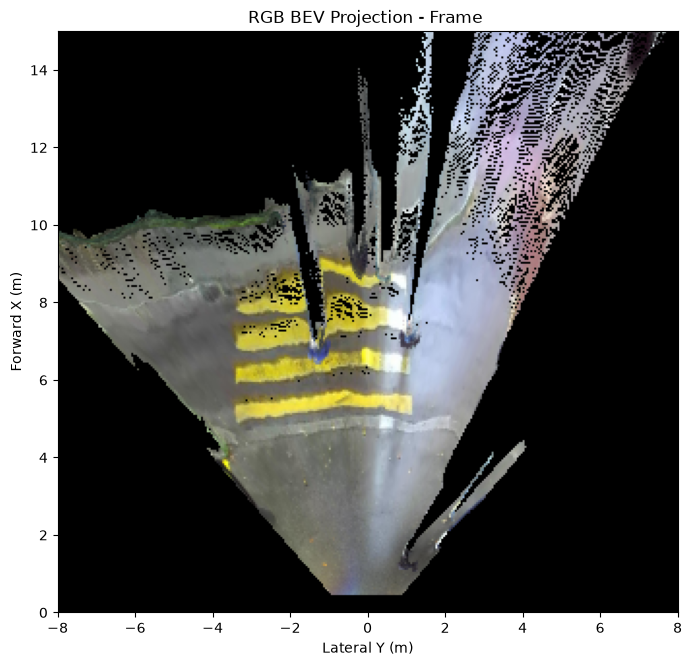

In [28]:
import matplotlib.pyplot as plt

plt.ion()
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Initialize axes labels once
ax.set_xlabel("Lateral Y (m)")
ax.set_ylabel("Forward X (m)")
title_text = ax.set_title("RGB BEV Projection - Frame ")
first_pcd = build_pcd(rgb_files[300], depth_files[300])
plane_coeffs, inlier_idx, near_pcd = fit_ground_plane(first_pcd, near_field_radius=5.0)
#heights = height_above_plane(np.asarray(first_pcd.points), plane_coeffs)
bev_map = generate_bev_from_o3d(first_pcd, x_range=X_RANGE, y_range=Y_RANGE)

rgb = np.transpose(bev_map[6:9], (1, 2, 0))
if np.nanmax(rgb) > 1.0:
    rgb = rgb / 255.0
rgb_vis = np.nan_to_num(rgb)

# Create image object ONCE
im = ax.imshow(rgb_vis, extent=[Y_RANGE[0], Y_RANGE[1], X_RANGE[0], X_RANGE[1]])


### Visualise Static BEV Map (Height Overlaid)

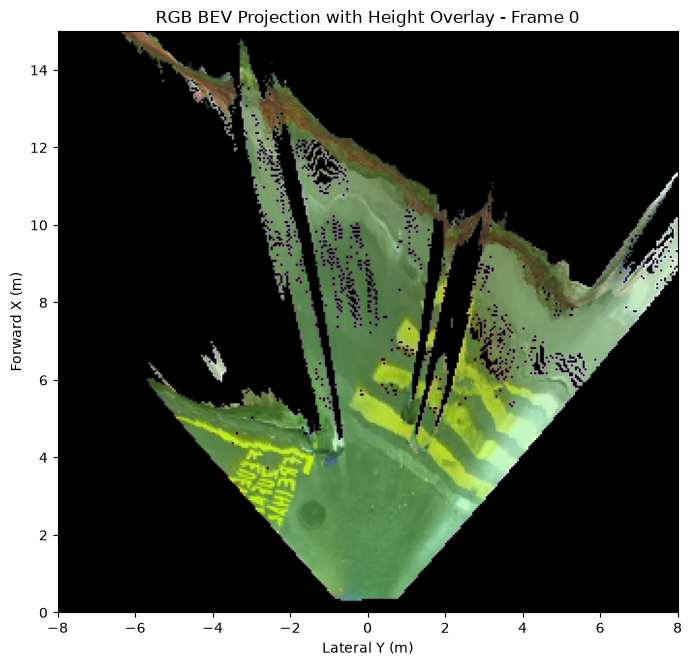

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.ion()
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Initialize axes labels once
ax.set_xlabel("Lateral Y (m)")
ax.set_ylabel("Forward X (m)")
title_text = ax.set_title("RGB BEV Projection with Height Overlay - Frame 0")

first_pcd = build_pcd(rgb_files[342], depth_files[342])
plane_coeffs, inlier_idx, near_pcd = fit_ground_plane(first_pcd, near_field_radius=5.0)
#heights = height_above_plane(np.asarray(first_pcd.points), plane_coeffs)
bev_map = generate_bev_from_o3d(first_pcd, x_range=X_RANGE, y_range=Y_RANGE)

# 2. Extract Base RGB Image
rgb = np.transpose(bev_map[6:9], (1, 2, 0))
if np.nanmax(rgb) > 1.0:
    rgb = rgb / 255.0
rgb_vis = np.nan_to_num(rgb)

# 3. Extract Height Metrics and Occupancy Mask
z_mean = bev_map[2]
z_std = bev_map[3]
occupied = bev_map[5] > 0
valid_mask = occupied & ~np.isnan(z_mean)

# 4. Normalize Height (z_mean) to range [0, 1]
if np.any(valid_mask):
    z_min_val = np.nanmin(z_mean[valid_mask])
    z_max_val = np.nanmax(z_mean[valid_mask])
    z_range = z_max_val - z_min_val if z_max_val != z_min_val else 1.0
    norm_height = np.clip((z_mean - z_min_val) / z_range, 0.0, 1.0)
else:
    norm_height = np.zeros_like(z_mean)

# Normalize z_std for opacity modulation
if np.any(valid_mask) and np.nanmax(z_std[valid_mask]) > 0:
    norm_std = np.clip(z_std / np.nanmax(z_std[valid_mask]), 0.0, 1.0)
else:
    norm_std = np.zeros_like(z_std)

# 5. Build RGBA Height Overlay (High -> Transparent Red, Low -> Transparent Green)
H, W = z_mean.shape
height_overlay = np.zeros((H, W, 4), dtype=np.float32)

height_overlay[..., 0] = norm_height          # Red: High elevation
height_overlay[..., 1] = 1.0 - norm_height    # Green: Low elevation
height_overlay[..., 2] = 0.0                  # Blue: Zero

# Set alpha transparency on occupied pixels; scale with z_std for structure detail
base_alpha = 0.4
alpha_channel = np.where(valid_mask, base_alpha * (0.6 + 0.4 * norm_std), 0.0)
height_overlay[..., 3] = alpha_channel

# 6. Render Base Image and Overlay
extent = [Y_RANGE[0], Y_RANGE[1], X_RANGE[0], X_RANGE[1]]
im_rgb = ax.imshow(rgb_vis, extent=extent)
im_overlay = ax.imshow(height_overlay, extent=extent)

### Visualise Dynamic BEV Map (Only RGB)

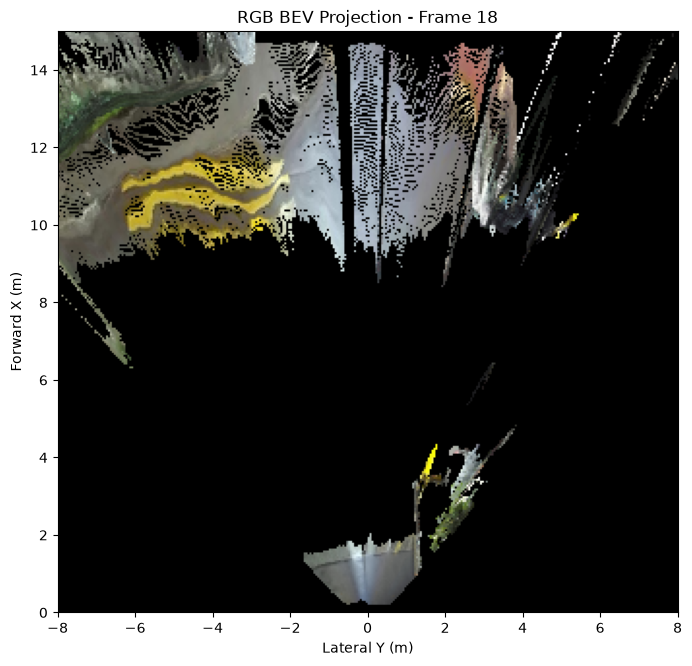

KeyboardInterrupt: 

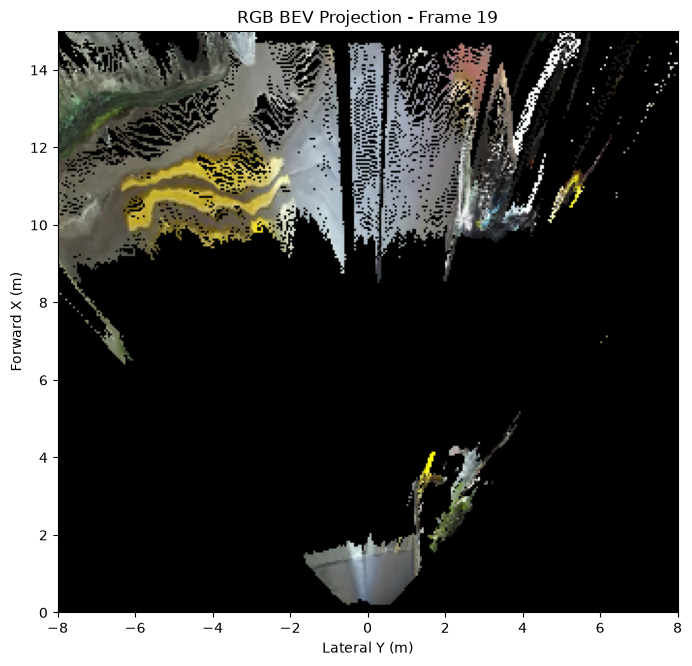

In [32]:

import numpy as np
from IPython.display import display, clear_output

plt.ion()
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Initialize axes labels once
ax.set_xlabel("Lateral Y (m)")
ax.set_ylabel("Forward X (m)")
title_text = ax.set_title("RGB BEV Projection - Frame 0")

# 2. Process first frame or initialize dummy image to establish spatial bounds
first_pcd = build_pcd(rgb_files[0], depth_files[0])
plane_coeffs, inlier_idx, near_pcd = fit_ground_plane(first_pcd, near_field_radius=5.0)
#heights = height_above_plane(np.asarray(first_pcd.points), plane_coeffs)
bev_map = generate_bev_from_o3d(first_pcd, x_range=X_RANGE, y_range=Y_RANGE)

rgb = np.transpose(bev_map[6:9], (1, 2, 0))
if np.nanmax(rgb) > 1.0:
    rgb = rgb / 255.0
rgb_vis = np.nan_to_num(rgb)

# Create image object ONCE
im = ax.imshow(rgb_vis, extent=[Y_RANGE[0], Y_RANGE[1], X_RANGE[0], X_RANGE[1]])

# 3. Animation loop
for i in range(0, len(rgb_files)):
    new_pcd = build_pcd(rgb_files[i], depth_files[i])

    # Fixed typo: passed `new_pcd` instead of `pcd`
    # plane_coeffs, inlier_idx, near_pcd = fit_ground_plane(new_pcd, near_field_radius=5.0)
    # heights = height_above_plane(np.asarray(new_pcd.points), plane_coeffs)

    bev_map = generate_bev_from_o3d(new_pcd, x_range=X_RANGE, y_range=Y_RANGE)
    
    rgb = np.transpose(bev_map[6:9], (1, 2, 0))
    if np.nanmax(rgb) > 1.0:
        rgb = rgb / 255.0
    rgb_vis = np.nan_to_num(rgb)

    # Update only image content and title text
    im.set_data(rgb_vis)
    title_text.set_text(f"RGB BEV Projection - Frame {i}")

    fig.canvas.draw_idle()
    clear_output(wait=True)
    display(fig)

plt.ioff()
plt.show()

### Visualise Dynamic BEV with Height overlay

KeyboardInterrupt: 

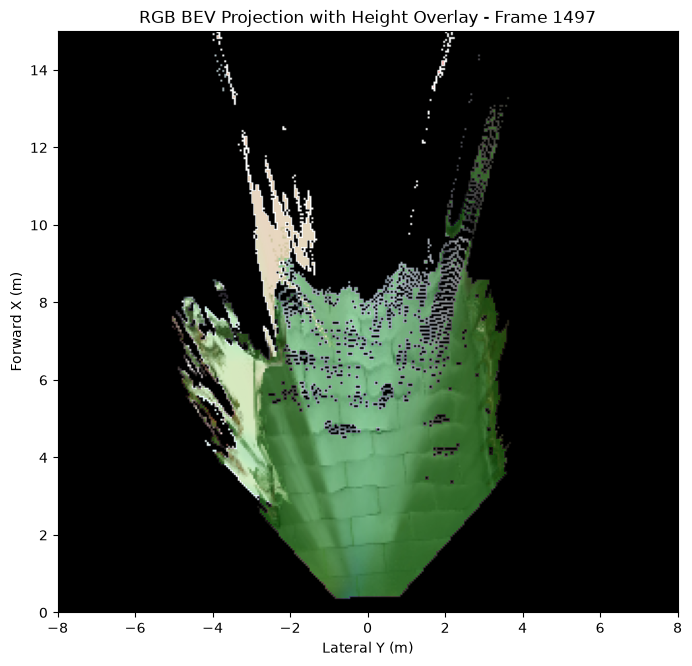

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output

def process_bev_layers(bev_map, base_alpha=0.4):
    """Extracts RGB background and builds RGBA height overlay from BEV map array."""
    # 1. Base RGB Processing
    rgb = np.transpose(bev_map[6:9], (1, 2, 0))
    if np.nanmax(rgb) > 1.0:
        rgb = rgb / 255.0
    rgb_vis = np.nan_to_num(rgb)

    # 2. Height Metrics and Occupancy Mask
    z_mean = bev_map[2]
    z_std = bev_map[3]
    occupied = bev_map[5] > 0
    valid_mask = occupied & ~np.isnan(z_mean)

    # 3. Normalize Mean Height (z_mean) to [0, 1]
    if np.any(valid_mask):
        z_min_val = np.nanmin(z_mean[valid_mask])
        z_max_val = np.nanmax(z_mean[valid_mask])
        z_range = z_max_val - z_min_val if z_max_val != z_min_val else 1.0
        norm_height = np.clip((z_mean - z_min_val) / z_range, 0.0, 1.0)
    else:
        norm_height = np.zeros_like(z_mean)

    # 4. Normalize Standard Deviation (z_std) for Opacity Scaling
    if np.any(valid_mask) and np.nanmax(z_std[valid_mask]) > 0:
        norm_std = np.clip(z_std / np.nanmax(z_std[valid_mask]), 0.0, 1.0)
    else:
        norm_std = np.zeros_like(z_std)

    # 5. Create RGBA Height Map (High -> Red, Low -> Green)
    H, W = z_mean.shape
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    overlay[..., 0] = norm_height          # Red: High elevation
    overlay[..., 1] = 1.0 - norm_height    # Green: Low elevation
    overlay[..., 2] = 0.0                  # Blue: Unused
    
    # Scale alpha by standard deviation (higher variance = higher opacity)
    alpha_channel = np.where(valid_mask, base_alpha * (0.6 + 0.4 * norm_std), 0.0)
    overlay[..., 3] = alpha_channel

    return rgb_vis, overlay


# --- Interactive Display Setup ---
plt.ion()
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Initialize axes labels once
ax.set_xlabel("Lateral Y (m)")
ax.set_ylabel("Forward X (m)")
title_text = ax.set_title("RGB BEV Projection with Height Overlay - Frame 0")

# 2. Process frame 0 to initialize image objects
first_pcd = build_pcd(rgb_files[0], depth_files[0])
bev_map = generate_bev_from_o3d(first_pcd, x_range=X_RANGE, y_range=Y_RANGE)
rgb_vis, height_overlay = process_bev_layers(bev_map)

# Create two stacked image objects ONCE (Base RGB and Height Overlay)
extent = [Y_RANGE[0], Y_RANGE[1], X_RANGE[0], X_RANGE[1]]
im_rgb = ax.imshow(rgb_vis, extent=extent)
im_overlay = ax.imshow(height_overlay, extent=extent)

# 3. Animation Loop
for i in range(len(rgb_files)):
    new_pcd = build_pcd(rgb_files[i], depth_files[i])
    bev_map = generate_bev_from_o3d(new_pcd, x_range=X_RANGE, y_range=Y_RANGE)

    # Generate updated layers
    rgb_vis, height_overlay = process_bev_layers(bev_map)

    # In-place data update for fast rendering
    im_rgb.set_data(rgb_vis)
    im_overlay.set_data(height_overlay)
    title_text.set_text(f"RGB BEV Projection with Height Overlay - Frame {i}")

    fig.canvas.draw_idle()
    clear_output(wait=True)
    display(fig)

plt.ioff()
plt.show()

### Dynamic BEV Height Map

KeyboardInterrupt: 

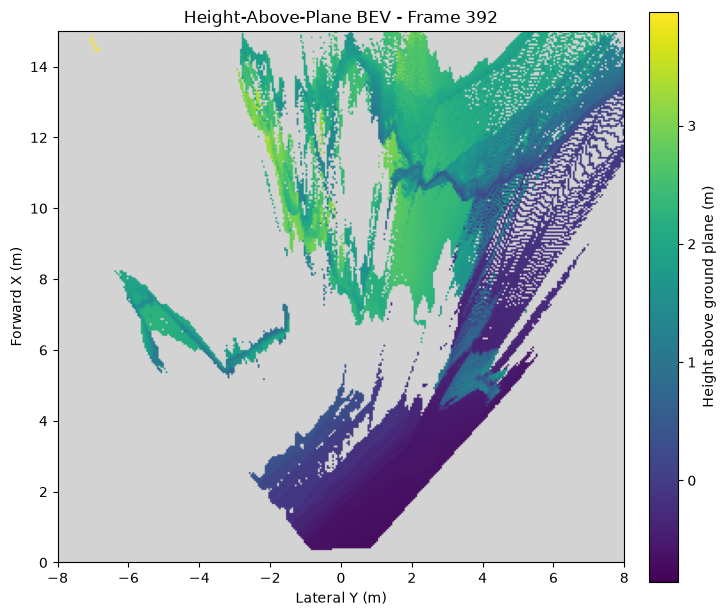

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

plt.ion()
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Initialize axes labels once
ax.set_xlabel("Lateral Y (m)")
ax.set_ylabel("Forward X (m)")
title_text = ax.set_title("Height-Above-Plane BEV - Frame 0")

HEIGHT_CH = 2  # index of height-above-plane channel in bev_map

# 2. Process first frame to establish spatial bounds + color scale
first_pcd = build_pcd(rgb_files[0], depth_files[0])
plane_coeffs, inlier_idx, near_pcd = fit_ground_plane(first_pcd, near_field_radius=5.0)
bev_map = generate_bev_from_o3d(first_pcd, x_range=X_RANGE, y_range=Y_RANGE)

height = bev_map[HEIGHT_CH]  # (H, W), NaN where unobserved

# Mask NaNs so they render as a distinct "unobserved" color rather than 0
height_masked = np.ma.masked_invalid(height)

# Fix color scale across the whole animation using a robust percentile range
# from the first frame (avoids outlier points blowing out the scale)
vmin, vmax = np.nanpercentile(height, [2, 98])

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="lightgray")  # unobserved cells

im = ax.imshow(
    height_masked,
    extent=[Y_RANGE[0], Y_RANGE[1], X_RANGE[0], X_RANGE[1]],
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Height above ground plane (m)")

# 3. Animation loop
for i in range(0, len(rgb_files)):
    new_pcd = build_pcd(rgb_files[i], depth_files[i])

    # Re-fit ground plane per frame (uncomment if not already handled inside generate_bev_from_o3d)
    # plane_coeffs, inlier_idx, near_pcd = fit_ground_plane(new_pcd, near_field_radius=5.0)

    bev_map = generate_bev_from_o3d(new_pcd, x_range=X_RANGE, y_range=Y_RANGE)
    height = bev_map[HEIGHT_CH]
    height_masked = np.ma.masked_invalid(height)

    # Update only image content and title text
    im.set_data(height_masked)
    title_text.set_text(f"Height-Above-Plane BEV - Frame {i}")

    fig.canvas.draw_idle()
    clear_output(wait=True)
    display(fig)

plt.ioff()
plt.show()